# Non-Gaussian Markov GP inference

`MarkovGPPrior` gives Kalman-filter-based linear-time inference for stationary 1-D GPs (`O(N\,d^3)` rather than `O(N^3)`). When the observation likelihood $p(y \mid f)$ is non-Gaussian (Bernoulli for binary time-series classification, Poisson for counts, StudentT for robust regression), the closed-form Kalman update no longer applies.

The site-based view recovers linear time. Each iteration replaces the true non-Gaussian likelihood with a Gaussian *site*

$$t_n(f_n) \propto \exp\bigl(\lambda_n f_n - \tfrac12 \Lambda_n f_n^2\bigr) \quad \Leftrightarrow\quad \mathcal{N}\bigl(f_n \mid \tilde y_n = \lambda_n / \Lambda_n,\; 1/\Lambda_n\bigr),$$

runs forward Kalman filter + RTS smoother on those *pseudo-observations* with per-step variance $1/\Lambda_n$, and refreshes $(\lambda, \Lambda)$ from local likelihood gradients/Hessians at the new posterior mean. Strategies (`LaplaceMarkovInference`, `GaussNewtonMarkovInference`, `PosteriorLinearizationMarkov`, `ExpectationPropagationMarkov`) differ only in *how* sites are refreshed.

This notebook shows Markov-Laplace on a Bernoulli time series and forecasts beyond the training window.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    BernoulliLikelihood,
    ExpectationPropagationMarkov,
    LaplaceMarkovInference,
    MarkovGPPrior,
    MaternSDE,
)


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(7)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic Bernoulli time series

Latent function $f(t) = 1.5\,\sin(2t) + 0.3\,\cos(7t)$, observations $y_n \sim \text{Bernoulli}(\sigma(f(t_n)))$ on an irregular grid.

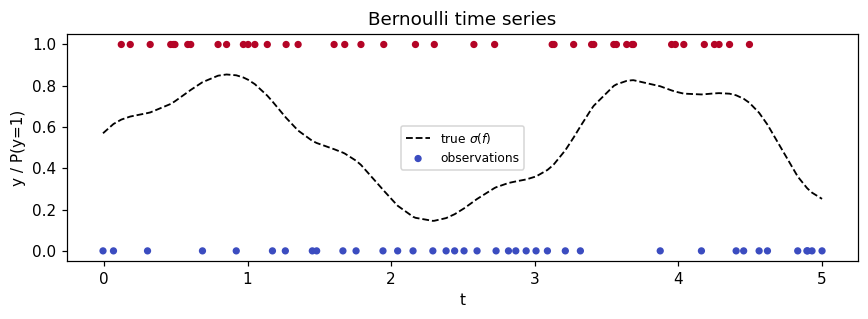

In [2]:
N = 80
t_uniform = jnp.linspace(0.0, 5.0, N)
jitter = 0.04 * jax.random.normal(jax.random.PRNGKey(1), (N,))
times = jnp.sort(t_uniform + jitter)
f_true = 1.5 * jnp.sin(2.0 * times) + 0.3 * jnp.cos(7.0 * times)
probs_true = jax.nn.sigmoid(f_true)
y = (jax.random.uniform(key, (N,)) < probs_true).astype(jnp.float32)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(times, probs_true, "k--", lw=1.2, label=r"true $\sigma(f)$")
ax.scatter(times, y, c=y, cmap="coolwarm", s=14, label="observations")
ax.set_xlabel("t")
ax.set_ylabel("y / P(y=1)")
ax.set_title("Bernoulli time series")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Fit Markov-Laplace

Matern-3/2 SDE prior (`order=1`), lengthscale 0.4, variance 1.0. Each Newton iteration runs Kalman filter + RTS smoother once.

In [3]:
sde = MaternSDE(variance=1.0, lengthscale=0.4, order=1)
prior = MarkovGPPrior(sde, times)
strategy = LaplaceMarkovInference(max_iter=30, tol=1e-6)
cond = strategy.fit(prior, BernoulliLikelihood(), y)

print(f"converged: {cond.converged}")
print(f"iterations used: {cond.n_iter}")
print(f"approximate log marginal: {float(cond.log_marginal_approx):.3f}")
print(
    f"posterior mean range: [{float(cond.q_mean.min()):.3f}, {float(cond.q_mean.max()):.3f}]"
)
print(
    f"posterior var range:  [{float(cond.q_var.min()):.4f}, {float(cond.q_var.max()):.4f}]"
)

converged: True
iterations used: 6
approximate log marginal: -53.466
posterior mean range: [-1.246, 1.188]
posterior var range:  [0.3476, 0.5669]


## Predict + forecast

Predict on a fine grid that extends *past* the training window. The merged-grid Kalman trick handles training-grid lookups, interpolation, and forecasting under one code path.

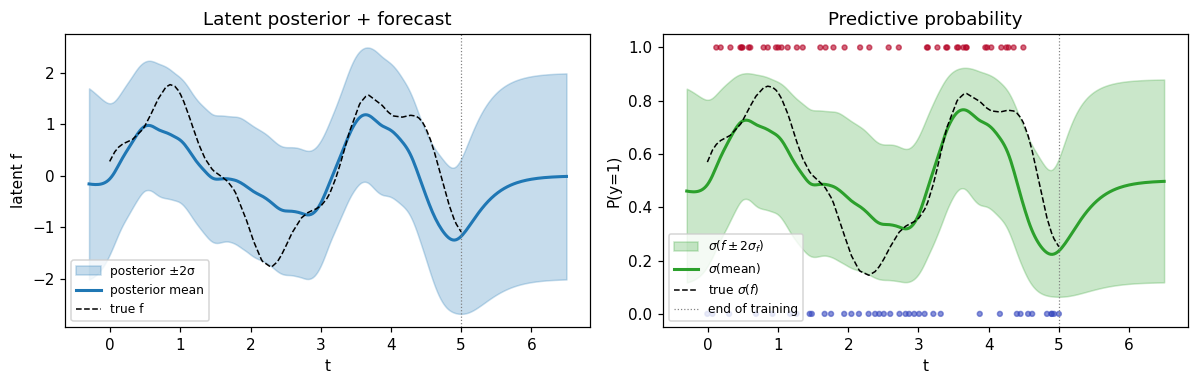

In [4]:
t_star = jnp.linspace(-0.3, 6.5, 300)
m_star, v_star = cond.predict(t_star)
m_star, v_star = np.asarray(m_star), np.asarray(v_star)
sd_star = np.sqrt(np.maximum(v_star, 0))
p_mean = jax.nn.sigmoid(m_star)
p_lo = jax.nn.sigmoid(m_star - 2.0 * sd_star)
p_hi = jax.nn.sigmoid(m_star + 2.0 * sd_star)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.fill_between(
    t_star,
    m_star - 2.0 * sd_star,
    m_star + 2.0 * sd_star,
    alpha=0.25,
    color="C0",
    label="posterior ±2σ",
)
ax.plot(t_star, m_star, color="C0", lw=2, label="posterior mean")
ax.plot(times, f_true, "k--", lw=1, label="true f")
ax.axvline(times[-1], color="grey", ls=":", lw=0.8)
ax.set_xlabel("t")
ax.set_ylabel("latent f")
ax.set_title("Latent posterior + forecast")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
ax.fill_between(
    t_star, p_lo, p_hi, alpha=0.25, color="C2", label=r"$\sigma(f \pm 2\sigma_f)$"
)
ax.plot(t_star, p_mean, color="C2", lw=2, label=r"$\sigma$(mean)")
ax.plot(times, probs_true, "k--", lw=1, label=r"true $\sigma(f)$")
ax.scatter(times, y, c=y, cmap="coolwarm", s=10, alpha=0.6)
ax.axvline(times[-1], color="grey", ls=":", lw=0.8, label="end of training")
ax.set_xlabel("t")
ax.set_ylabel("P(y=1)")
ax.set_title("Predictive probability")
ax.legend(loc="lower left", fontsize=8)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Past the dotted line (last training point) the posterior reverts to the prior mean (zero) with the prior variance (`MaternSDE.variance = 1`), as expected — no observation pulls $f$ in any direction beyond the data.

## Compare Laplace vs EP

EP matches the *moments* of the cavity-times-likelihood tilted distribution rather than the mode; on log-concave likelihoods the two strategies sit close.

EP converged: True, iters: 17
max |Laplace − EP| posterior mean: 0.0621
max |Laplace − EP| posterior var:  0.0229


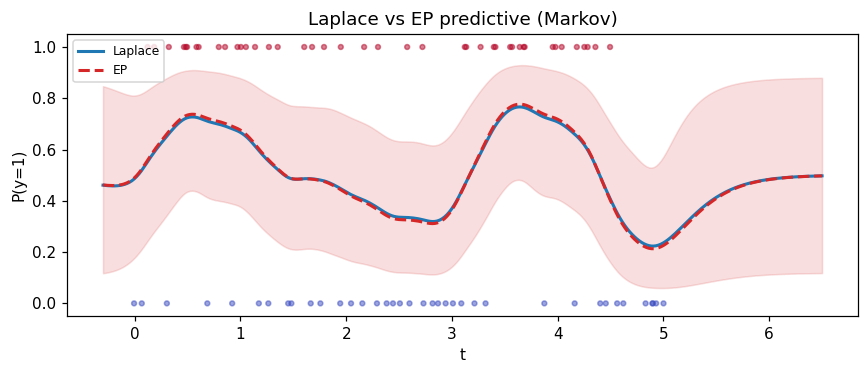

In [5]:
ep = ExpectationPropagationMarkov(max_iter=40, tol=1e-5, damping=0.5).fit(
    prior, BernoulliLikelihood(), y
)
print(f"EP converged: {ep.converged}, iters: {ep.n_iter}")
print(
    f"max |Laplace − EP| posterior mean: {float(jnp.max(jnp.abs(cond.q_mean - ep.q_mean))):.4f}"
)
print(
    f"max |Laplace − EP| posterior var:  {float(jnp.max(jnp.abs(cond.q_var - ep.q_var))):.4f}"
)

m_lap, _ = cond.predict(t_star)
m_ep, v_ep = ep.predict(t_star)
m_lap = np.asarray(m_lap)
m_ep = np.asarray(m_ep)
v_ep = np.asarray(v_ep)
sd_ep = np.sqrt(np.maximum(v_ep, 0))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_star, jax.nn.sigmoid(m_lap), color="C0", lw=2, label="Laplace")
ax.plot(t_star, jax.nn.sigmoid(m_ep), color="C3", lw=2, ls="--", label="EP")
ax.fill_between(
    t_star,
    jax.nn.sigmoid(m_ep - 2 * sd_ep),
    jax.nn.sigmoid(m_ep + 2 * sd_ep),
    alpha=0.15,
    color="C3",
)
ax.scatter(times, y, c=y, cmap="coolwarm", s=10, alpha=0.5)
ax.set_xlabel("t")
ax.set_ylabel("P(y=1)")
ax.set_title("Laplace vs EP predictive (Markov)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

- `LaplaceMarkovInference` and friends fit non-Gaussian likelihoods on `MarkovGPPrior` in linear time.
- Each iteration is one Kalman filter + RTS smoother with per-step pseudo-observation variance `1/Lambda_n`.
- Predictions handle training-grid lookups, interpolation, and forecasting through one merged-grid pass.
- Outside the training window the posterior reverts to the SDE prior — the right behavior for stationary state-space kernels.